<!-- # Spatial Disorder & Localisation

Real-space analysis of lower polariton localisation in a 2-D
Gaussian-correlated disorder potential.

**Contents**
1. Single realisation — disorder landscape and lowest eigenmodes
2. Sigma sweep — effective interaction strength vs disorder amplitude
3. (Optional) Xi sweep — correlation-length dependence of IPR -->


In [2]:
import sys
sys.path.insert(0, '.')

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from polaritons.real_space import (
	gaussian_correlated_disorder,
	lp_hamiltonian,
	solve_low_modes,
	normalize_mode,
	ipr,
	mode_area,
	g_eff_lowest_mode,
)
from polaritons.io import save_result
from polaritons.parameters import DEFAULT_PARAMS

# ---------------------------------------------------------------------------
# Matplotlib style
# ---------------------------------------------------------------------------
CMAP_NAME = "magma"
CMAP = plt.get_cmap(CMAP_NAME)

plt.rcParams.update({
	'font.family': 'serif',
	'font.size': 13,
	'axes.labelsize': 14,
	'axes.titlesize': 14,
	'figure.titlesize': 16,
	'image.cmap': CMAP_NAME,
})

REAL_SPACE_PLOTS_DIR = Path("Plots") / "Real_Space"
REAL_SPACE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Physical constants (SI, eV-based)
# ---------------------------------------------------------------------------
hbar = 6.582119569e-16   # eV·s
m0   = 5.685630e-12      # eV·s²/m²  (free electron rest mass)

# ---------------------------------------------------------------------------
# System parameters
# ---------------------------------------------------------------------------
N = 256                  # grid points per side
L = 40e-6                # system size (m)

M_lp = 1e-5 * m0         # LP effective mass
xi   = 20e-9             # disorder correlation length (m)

# Express everything as a *relative* interaction strength: g_eff / g_lp.
# With g_lp set to 1, g_eff equals the IPR (= 1/mode_area), which is the
# dimensionless suppression/enhancement of the lowest-mode interaction
# relative to the homogeneous (clean) case.
g_lp = 1.0
G_PLOT_LABEL = r"relative interaction strength  $g_{\rm eff}/g_{\rm lp}$"
AREA_PLOT_LABEL = r"mode area $A_{\rm eff}$ (µm$^2$)"

print(f"Grid: {N}×{N},  L={L*1e6:.0f} µm,  dx={L/N*1e9:.1f} nm")
print(f"M_lp = {M_lp:.3e} eV·s²/m²   xi = {xi*1e9:.0f} nm")
print(f"g_lp = {g_lp}  (relative units)")


Grid: 256×256,  L=40 µm,  dx=156.2 nm
M_lp = 5.686e-17 eV·s²/m²   xi = 20 nm
g_lp = 1.0  (relative units)


## 1 — Single realisation

Visualise the disorder landscape and the three lowest polariton eigenmodes.


  sigma (meV)   mode    E (meV)        A_eff (µm²)     g_eff / g_lp
       0.20    0        0.0462         711.288      1.0000e+00
       0.20    1        0.1157         643.723      1.1050e+00
       0.20    2        0.1174         650.246      1.0939e+00
       0.20    3        0.1866         713.948      9.9627e-01
       0.20    4        0.2325         628.740      1.1313e+00
       0.20    5        0.2334         631.713      1.1260e+00
       0.50    0        0.0446         699.981      1.0000e+00
       0.50    1        0.1136         632.895      1.1060e+00
       0.50    2        0.1177         649.308      1.0780e+00
       0.50    3        0.1860         707.723      9.8906e-01
       0.50    4        0.2303         610.615      1.1464e+00
       0.50    5        0.2330         623.174      1.1233e+00
       1.00    0        0.0397         674.336      1.0000e+00
       1.00    1        0.1078         609.610      1.1062e+00
       1.00    2        0.1160         641.135    

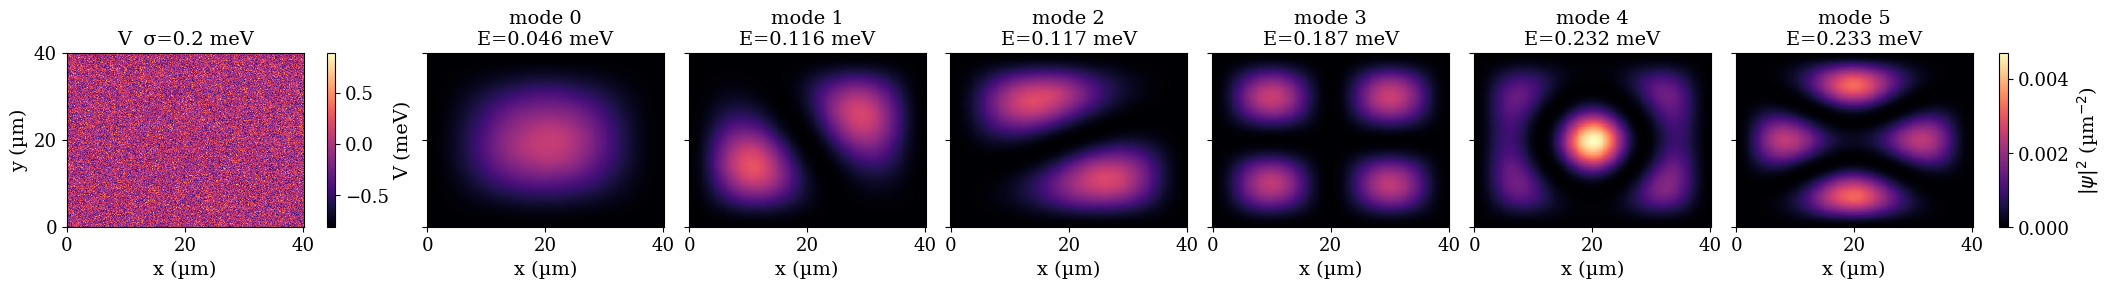

Saved  Plots/Real_Space/modes_sigma_0p5meV.png


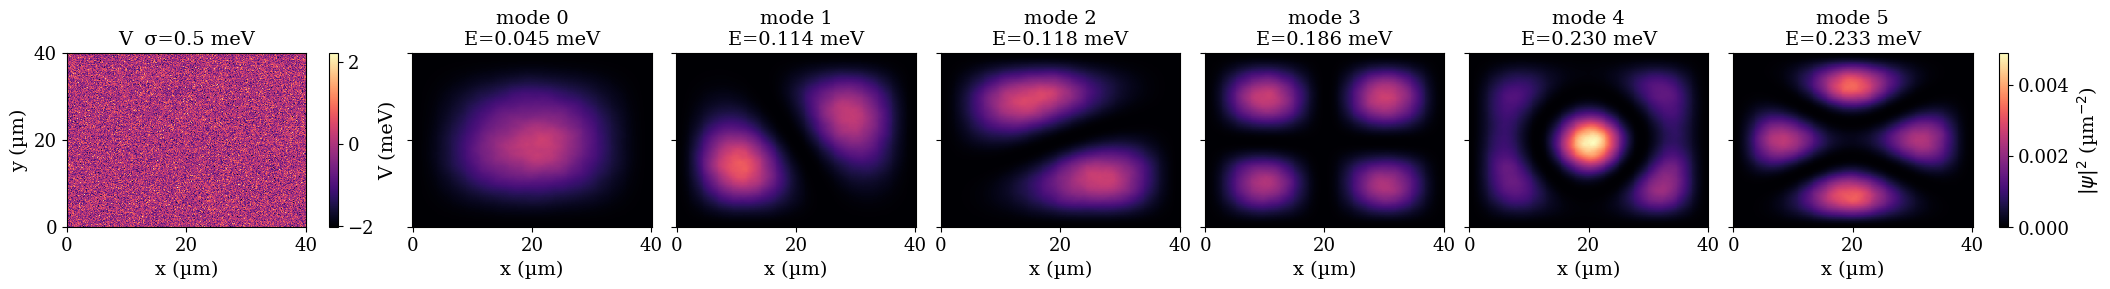

Saved  Plots/Real_Space/modes_sigma_1meV.png


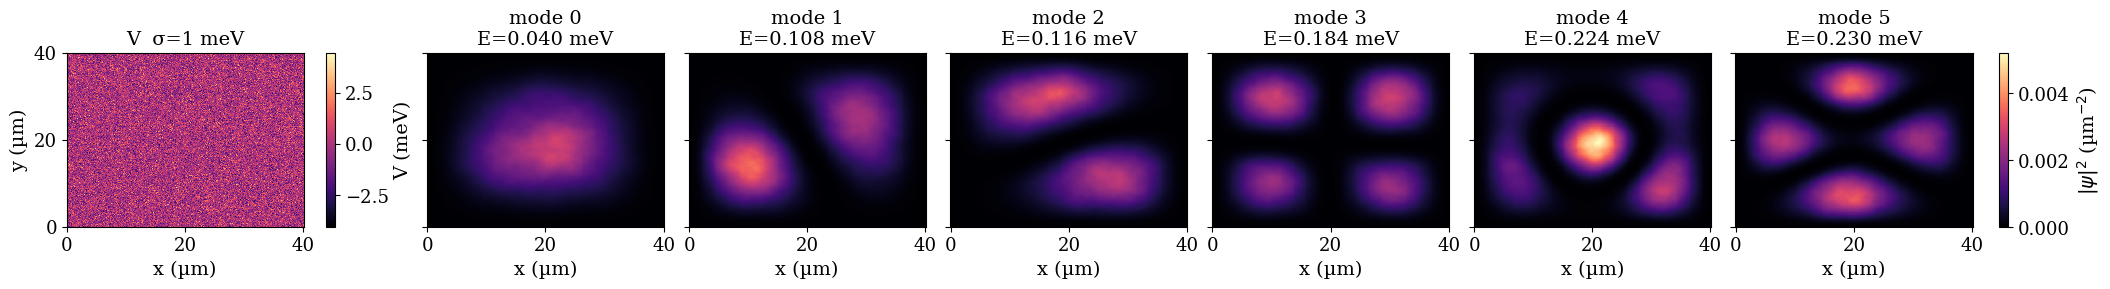

Saved  Plots/Real_Space/modes_sigma_2meV.png


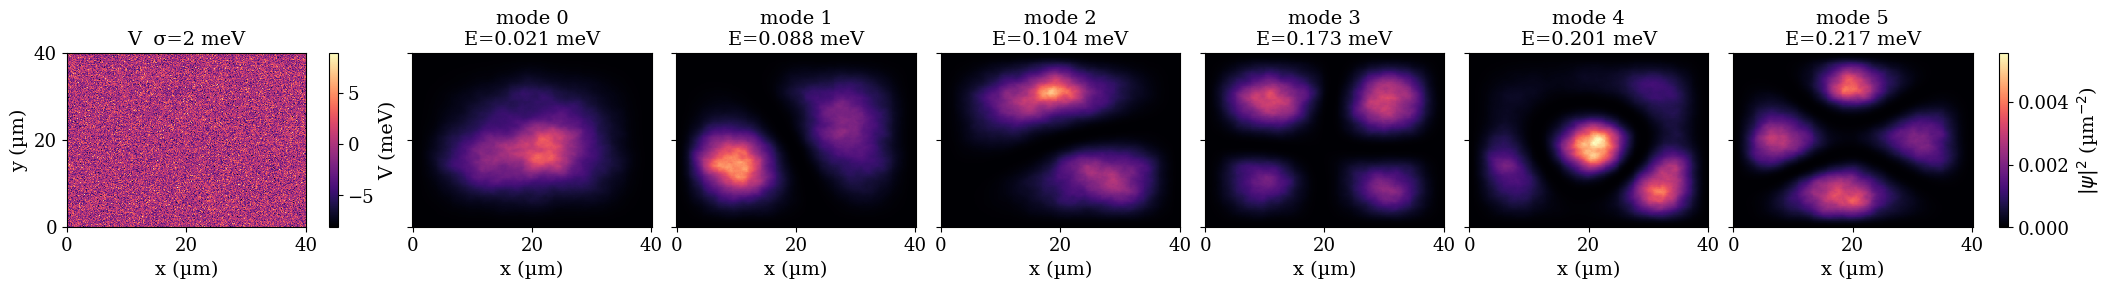

Saved  Plots/Real_Space/modes_sigma_5meV.png


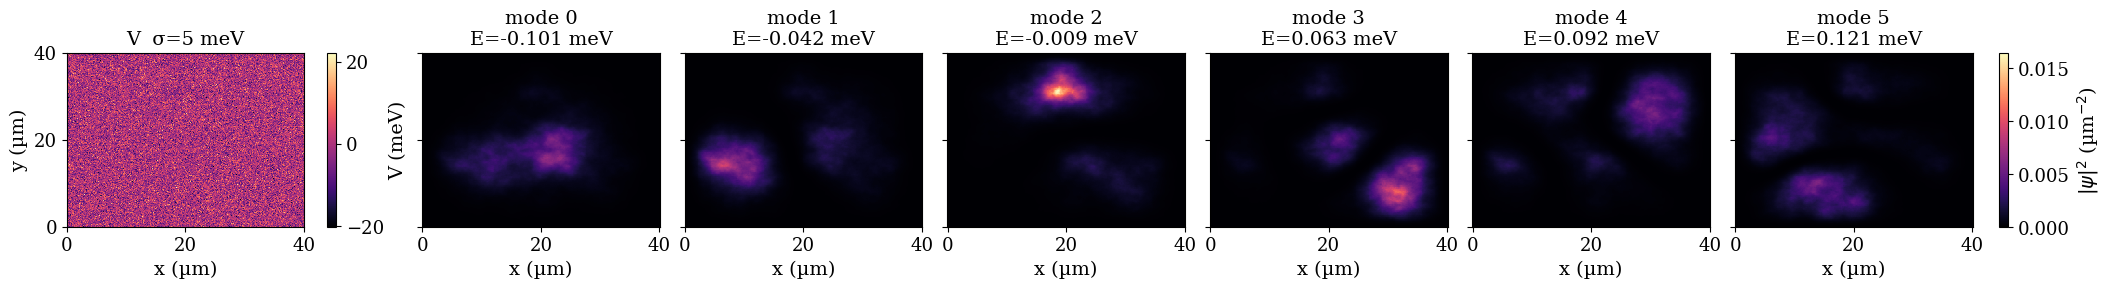

Saved  Plots/Real_Space/modes_sigma_10meV.png


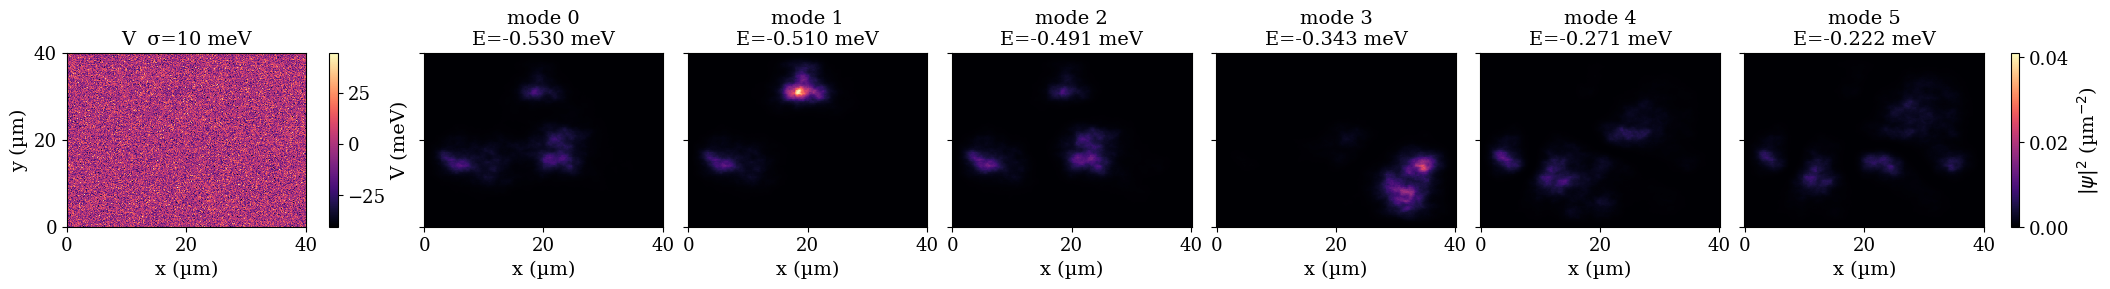

Saved  Plots/Real_Space/mode_evolution.png


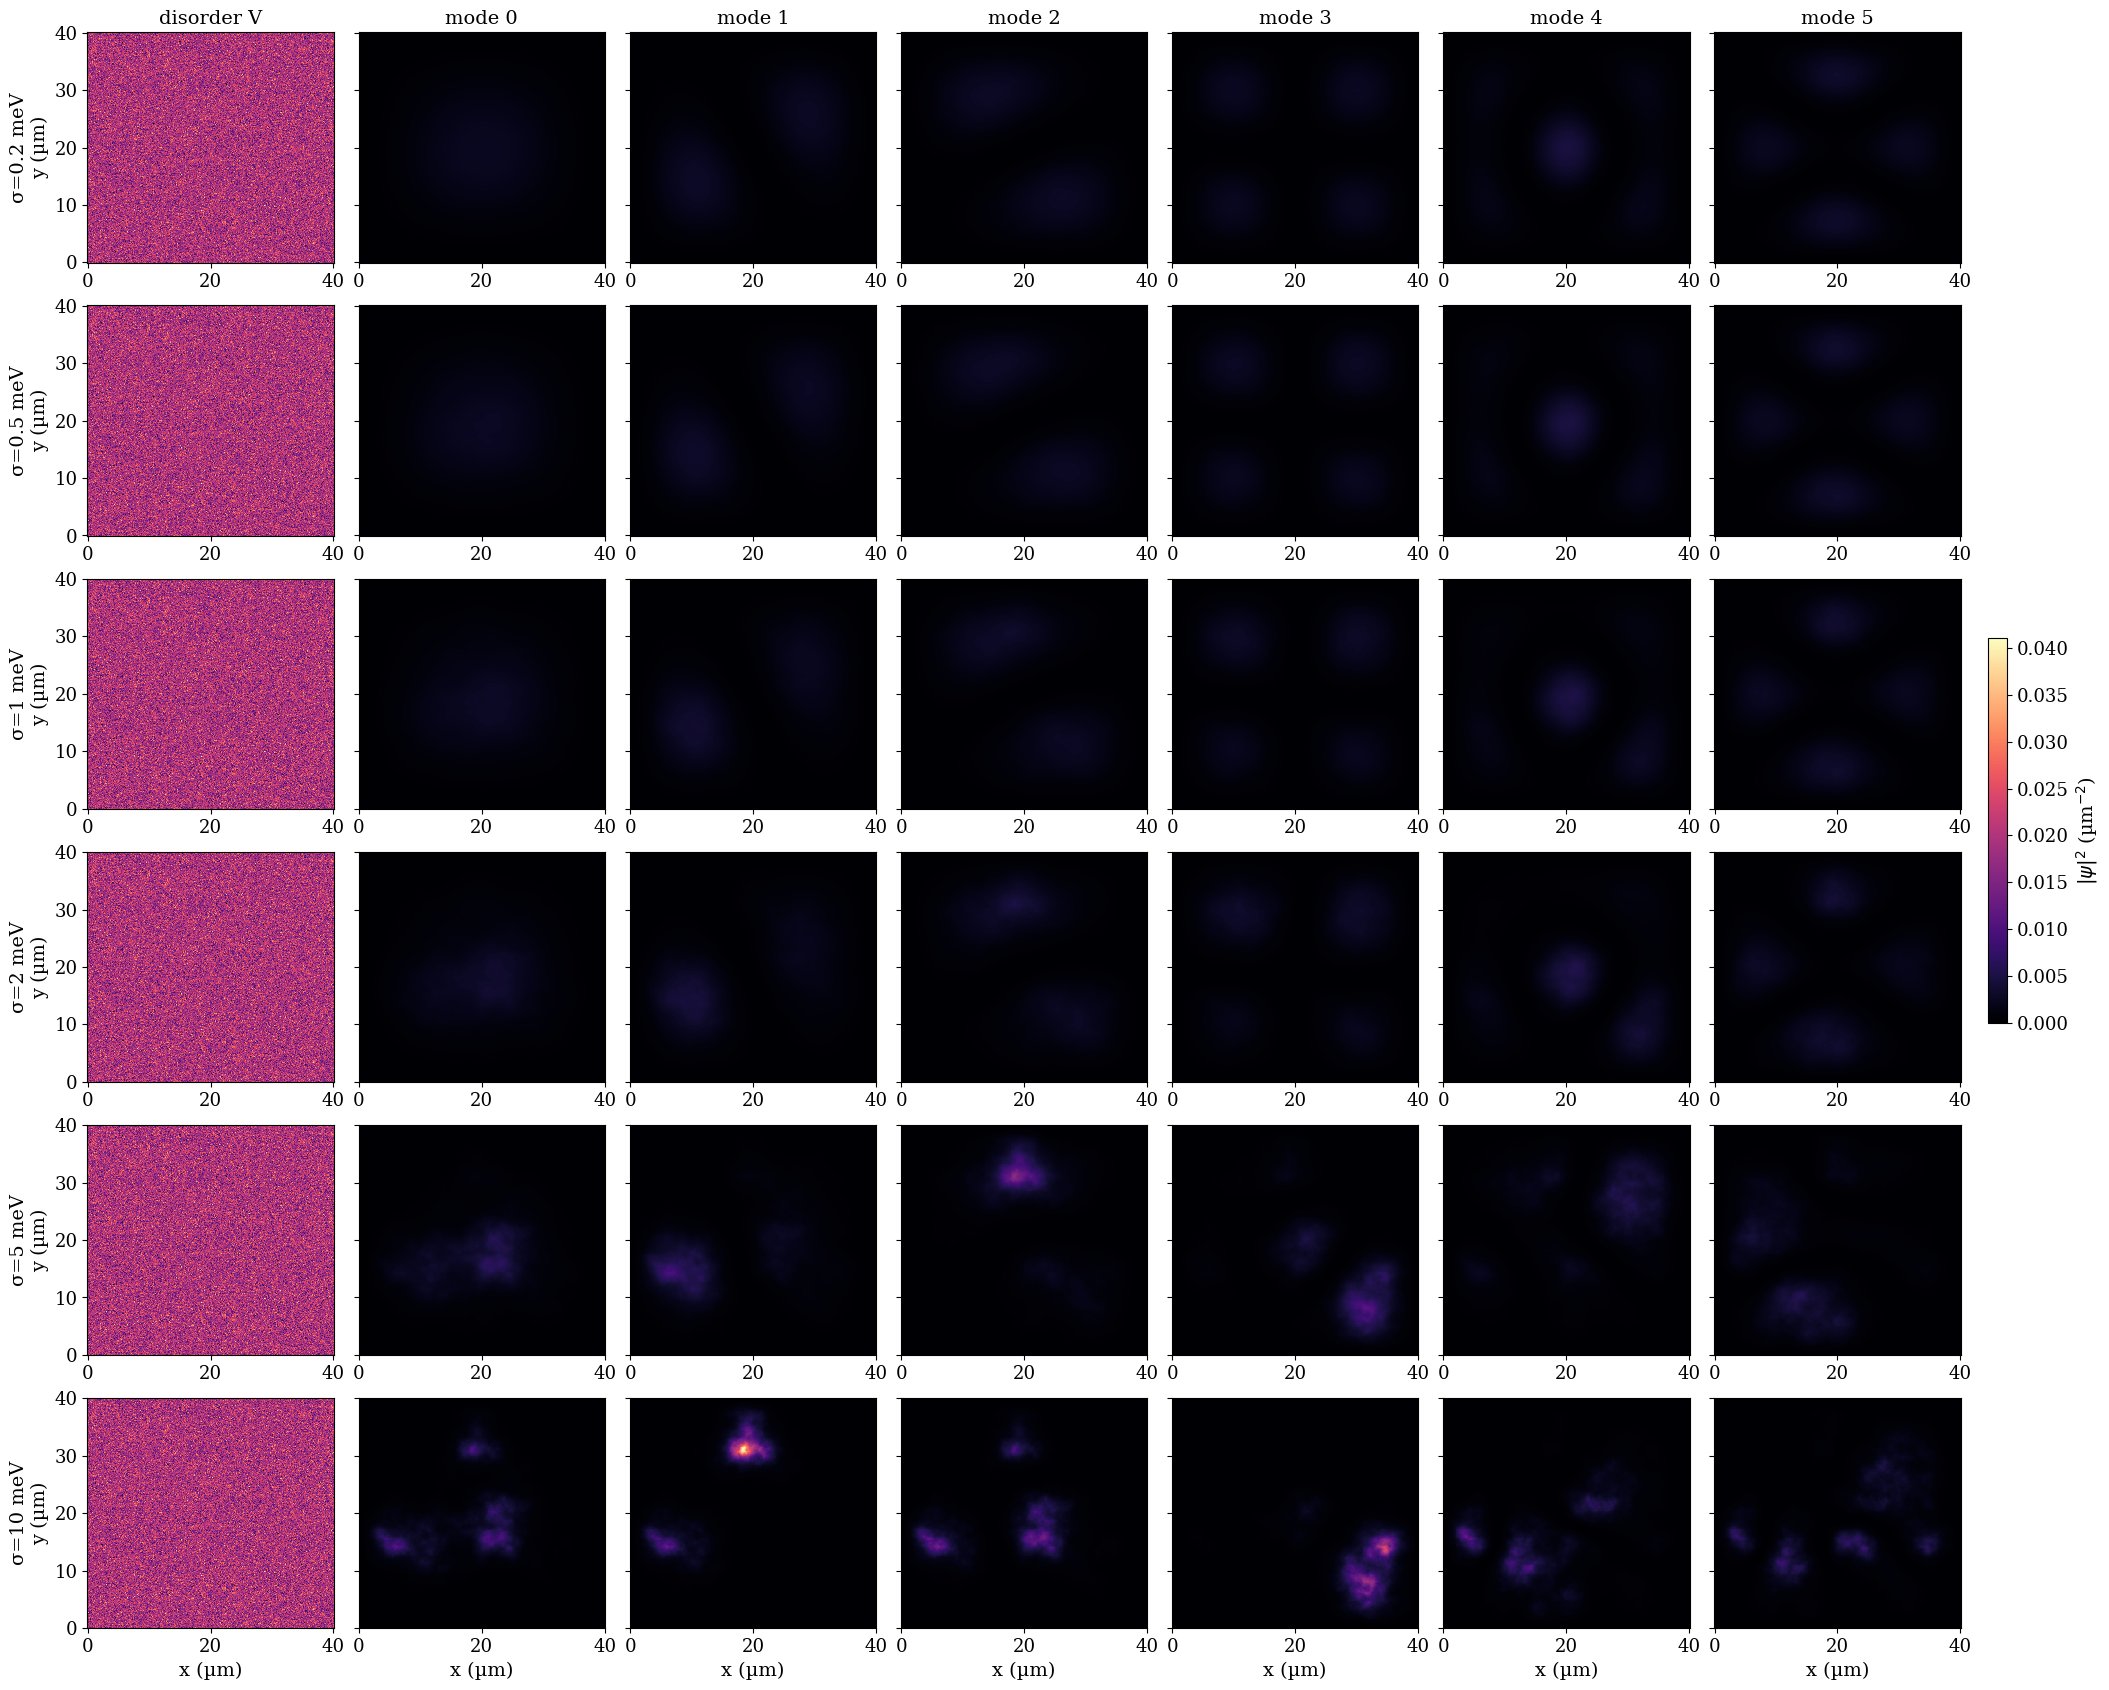

In [2]:
SEED          = 1
N_MODES       = 6
SIGMA_VALUES  = np.array([0.2, 0.5, 1.0, 2.0, 5.0, 10.0]) * 1e-3   # eV
dx            = L / N

x_um = np.linspace(0, L * 1e6, N)
X, Y = np.meshgrid(x_um, x_um, indexing="ij")

# Probability density |psi|^2 has units m^-2 (since modes are L^2-normalised
# in metres).  Convert to inverse square micrometres for plotting:
#    |psi|^2 [µm^-2]  =  1e-12 * |psi|^2 [m^-2]
PROB_DENSITY_TO_INV_UM2 = 1e-12
PROB_DENSITY_LABEL      = r"$|\psi|^2$ (µm$^{-2}$)"


def _sigma_slug(sigma_eV: float) -> str:
	# 0.5 meV -> "0p5meV"
	return f"{sigma_eV * 1e3:g}meV".replace(".", "p")


# Pre-compute disorder + modes for every sigma so we can build a composite
# figure with consistent per-sigma color scales.
landscapes  = []   # list of (sigma, V) pairs
mode_stacks = []   # list of (sigma, energies, modes) triples

print(f"  sigma (meV)   mode    E (meV)        A_eff (µm²)     g_eff / g_lp")
for sigma in SIGMA_VALUES:
	V = gaussian_correlated_disorder(N, L, float(sigma), xi, seed=SEED)
	H = lp_hamiltonian(N, L, M_lp, V, hbar)
	E, psi = solve_low_modes(H, n_modes=N_MODES)
	modes = [normalize_mode(psi[:, n].reshape(N, N), dx) for n in range(psi.shape[1])]

	landscapes.append((float(sigma), V))
	mode_stacks.append((float(sigma), E, modes))

	for n, m in enumerate(modes):
		A_eff_um2 = mode_area(m, dx) * 1e12
		rel_g     = g_lp * ipr(m, dx) / ipr(modes[0], dx)  # rel. to ground; g_lp=1
		print(f"  {sigma*1e3:9.2f}    {n}    {1e3*E[n]:10.4f}    {A_eff_um2:12.3f}    {rel_g:12.4e}")

# ---------------------------------------------------------------------------
# Per-sigma row figures: V + |psi|^2 for the N_MODES lowest modes,
# probability densities sharing the same color scale within each row.
# ---------------------------------------------------------------------------
panel_w, panel_h = 3.0, 2.8
ncols = 1 + N_MODES

per_sigma_paths = []

for (sigma, V), (_, E, modes) in zip(landscapes, mode_stacks):
	fig, axes = plt.subplots(1, ncols, figsize=(panel_w * ncols, panel_h), constrained_layout=True)
	# Disorder landscape (its own color scale).
	im_V = axes[0].pcolormesh(X, Y, 1e3 * V, shading="auto", cmap=CMAP_NAME)
	axes[0].set_title(f"V  σ={sigma*1e3:.2g} meV")
	axes[0].set_xlabel("x (µm)")
	axes[0].set_ylabel("y (µm)")
	plt.colorbar(im_V, ax=axes[0], fraction=0.046, label="V (meV)")

	# Probability densities in µm^-2: shared row-level color scale.
	prob_densities = [PROB_DENSITY_TO_INV_UM2 * np.abs(m) ** 2 for m in modes]
	vmin = 0.0
	vmax = float(max(np.max(p) for p in prob_densities))

	for n, prob in enumerate(prob_densities):
		ax = axes[1 + n]
		im = ax.pcolormesh(X, Y, prob, shading="auto",
						   cmap=CMAP_NAME, vmin=vmin, vmax=vmax)
		ax.set_title(f"mode {n}\nE={1e3*E[n]:.3f} meV")
		ax.set_xlabel("x (µm)")
		ax.set_yticklabels([])
	# One shared colorbar for the row of probability densities.
	plt.colorbar(im, ax=axes[1:], fraction=0.025, pad=0.01, label=PROB_DENSITY_LABEL)

	out_path = REAL_SPACE_PLOTS_DIR / f"modes_sigma_{_sigma_slug(sigma)}.png"
	fig.savefig(out_path, dpi=150, bbox_inches="tight")
	per_sigma_paths.append(out_path)
	print(f"Saved  {out_path}")
	plt.show()
	plt.close(fig)

# ---------------------------------------------------------------------------
# Composite figure: one row per sigma, columns = V + N_MODES eigenmodes.
# Probability densities share one global color scale so disorder-driven
# localisation is directly comparable across rows.
# ---------------------------------------------------------------------------
nrows = len(SIGMA_VALUES)
fig, axes = plt.subplots(nrows, ncols, figsize=(panel_w * ncols, panel_h * nrows),constrained_layout=True)
if nrows == 1:
	axes = axes[np.newaxis, :]

# Use np.max per-array to obtain a scalar before reducing with Python's max,
# otherwise max() compares whole arrays element-wise (ambiguous truth value).
global_vmax = float(max(
	np.max(PROB_DENSITY_TO_INV_UM2 * np.abs(m) ** 2)
	for (_, _, modes) in mode_stacks
	for m in modes
))

for row, ((sigma, V), (_, E, modes)) in enumerate(zip(landscapes, mode_stacks)):
	axes[row, 0].pcolormesh(X, Y, 1e3 * V, shading="auto", cmap=CMAP_NAME)
	axes[row, 0].set_ylabel(f"σ={sigma*1e3:.2g} meV\ny (µm)")
	if row == 0:
		axes[row, 0].set_title("disorder V")
	if row == nrows - 1:
		axes[row, 0].set_xlabel("x (µm)")

	for n, m in enumerate(modes):
		ax = axes[row, 1 + n]
		im = ax.pcolormesh(X, Y, PROB_DENSITY_TO_INV_UM2 * np.abs(m) ** 2,
						   shading="auto",
						   cmap=CMAP_NAME, vmin=0.0, vmax=global_vmax)
		if row == 0:
			ax.set_title(f"mode {n}")
		if row == nrows - 1:
			ax.set_xlabel("x (µm)")
		ax.set_yticklabels([])

fig.colorbar(im, ax=axes[:, 1:], fraction=0.012, pad=0.01,label=PROB_DENSITY_LABEL)
composite_path = REAL_SPACE_PLOTS_DIR / "mode_evolution.png"
fig.savefig(composite_path, dpi=150, bbox_inches="tight")
print(f"Saved  {composite_path}")
plt.show()
plt.close(fig)


## 2 — Sigma sweep

Average `g_eff` of the ground mode over multiple disorder realisations
as a function of disorder amplitude σ.  Results are saved to `Results/`.


  σ= 0.00 meV  →  g_eff/g_lp = 1.3953e+09 ± 3.7359e-04
  σ= 0.02 meV  →  g_eff/g_lp = 1.3961e+09 ± 1.6211e+06
  σ= 0.05 meV  →  g_eff/g_lp = 1.3974e+09 ± 4.0456e+06
  σ= 0.10 meV  →  g_eff/g_lp = 1.3997e+09 ± 8.0695e+06
  σ= 0.20 meV  →  g_eff/g_lp = 1.4050e+09 ± 1.6066e+07
  σ= 0.50 meV  →  g_eff/g_lp = 1.4265e+09 ± 3.9874e+07
  σ= 1.00 meV  →  g_eff/g_lp = 1.4805e+09 ± 8.0021e+07
Saved  geff_sigma_6fa6cb.npy  [3, 7] float64


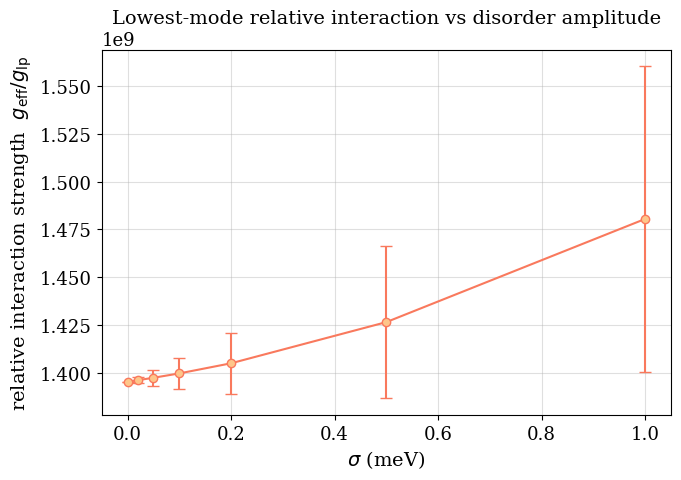

In [3]:
from polaritons.io import save_result, make_sweep_stem
from polaritons.parameters import DEFAULT_PARAMS

# ---------------------------------------------------------------------------
# Sweep configuration
# ---------------------------------------------------------------------------
sigmas = np.array([0.0, 0.02e-3, 0.05e-3, 0.1e-3, 0.2e-3, 0.5e-3, 1.0e-3])  # eV
n_realisations = 20

# ---------------------------------------------------------------------------
# Compute: relative interaction strength = g_eff / g_lp = IPR (since g_lp=1).
# Reported as the lowest-mode value.
# ---------------------------------------------------------------------------
g_mean = np.zeros(len(sigmas))
g_std  = np.zeros(len(sigmas))

for si, s in enumerate(sigmas):
	vals = [
		g_eff_lowest_mode(N, L, M_lp, s, xi, hbar, g_lp=g_lp, seed=seed)
		for seed in range(n_realisations)
	]
	g_mean[si] = np.mean(vals)
	g_std[si]  = np.std(vals)
	print(f"  σ={s*1e3:5.2f} meV  →  g_eff/g_lp = {g_mean[si]:.4e} ± {g_std[si]:.4e}")

# ---------------------------------------------------------------------------
# Save results
# ---------------------------------------------------------------------------
result_array = np.vstack([sigmas, g_mean, g_std])   # shape (3, len(sigmas))

extra_meta = {
	"rows"           : ["sigma_eV", "g_rel_mean", "g_rel_std"],
	"N"              : N,
	"L_m"            : L,
	"M_lp_eVs2m2"    : M_lp,
	"xi_m"           : xi,
	"g_lp"           : g_lp,
	"plot_units"     : "g_eff / g_lp (dimensionless)",
	"n_realisations" : n_realisations,
	"hbar_eVs"       : hbar,
}
stem = make_sweep_stem("geff_sigma", DEFAULT_PARAMS, extra={"xi": xi, "N": N})
save_result(result_array, "Results/interaction_strengths", stem, DEFAULT_PARAMS, extra_meta)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(1e3 * sigmas, g_mean, yerr=g_std,
			marker='o', capsize=4, linewidth=1.5,
			color=CMAP(0.72), markerfacecolor=CMAP(0.88))
ax.set_xlabel(r"$\sigma$ (meV)")
ax.set_ylabel(G_PLOT_LABEL)
ax.set_title(r"Lowest-mode relative interaction vs disorder amplitude")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 3 — Xi sweep  *(optional)*

Repeat the ground-mode IPR analysis across a range of correlation lengths ξ
at fixed disorder amplitude.


  ξ=    5 nm  →  g_eff/g_lp = 1.4050e+09 ± 1.5089e+07
  ξ=   10 nm  →  g_eff/g_lp = 1.4051e+09 ± 1.5165e+07
  ξ=   20 nm  →  g_eff/g_lp = 1.4053e+09 ± 1.5466e+07
  ξ=   40 nm  →  g_eff/g_lp = 1.4062e+09 ± 1.6680e+07
  ξ=   80 nm  →  g_eff/g_lp = 1.4102e+09 ± 2.1553e+07
Saved  geff_xi_4bfeb2.npy  [3, 5] float64


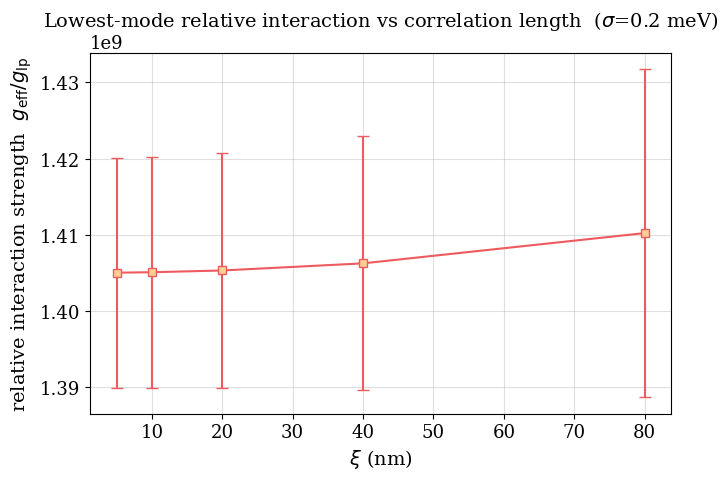

In [4]:
xis            = np.array([5e-9, 10e-9, 20e-9, 40e-9, 80e-9])  # m
sigma_fixed    = 0.2e-3   # eV — held constant
n_realisations = 10

xi_g_mean = np.zeros(len(xis))
xi_g_std  = np.zeros(len(xis))

for xi_i, xi_val in enumerate(xis):
	vals = [
		g_eff_lowest_mode(N, L, M_lp, sigma_fixed, xi_val, hbar, g_lp=g_lp, seed=seed)
		for seed in range(n_realisations)
	]
	xi_g_mean[xi_i] = np.mean(vals)
	xi_g_std[xi_i]  = np.std(vals)
	print(f"  ξ={xi_val*1e9:5.0f} nm  →  g_eff/g_lp = {xi_g_mean[xi_i]:.4e} ± {xi_g_std[xi_i]:.4e}")

# Save
result_xi = np.vstack([xis, xi_g_mean, xi_g_std])
extra_xi = {
	"rows"           : ["xi_m", "g_rel_mean", "g_rel_std"],
	"sigma_eV"       : sigma_fixed,
	"N"              : N,
	"L_m"            : L,
	"M_lp_eVs2m2"    : M_lp,
	"g_lp"           : g_lp,
	"plot_units"     : "g_eff / g_lp (dimensionless)",
	"n_realisations" : n_realisations,
}
stem_xi = make_sweep_stem("geff_xi", DEFAULT_PARAMS, extra={"sigma": sigma_fixed, "N": N})
save_result(result_xi, "Results/interaction_strengths", stem_xi, DEFAULT_PARAMS, extra_xi)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(xis * 1e9, xi_g_mean, yerr=xi_g_std,
			marker='s', capsize=4, linewidth=1.5,
			color=CMAP(0.65), markerfacecolor=CMAP(0.9))
ax.set_xlabel(r"$\xi$ (nm)")
ax.set_ylabel(G_PLOT_LABEL)
ax.set_title(fr"Lowest-mode relative interaction vs correlation length  ($\sigma$={sigma_fixed*1e3:.1f} meV)")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 4 — Extracting a real-space analogue of $Q(k)$

This section computes the disorder-averaged momentum-diagonal Green function
$\overline{G}(k,E)$ for a real-space Gaussian disorder model and extracts

$$Q_{\rm real}(k,E)=\overline{G}(k,E)^{-1}-(E+i\epsilon-\epsilon_k).$$

This is the direct object to compare against the CPA convention
$G_{\rm CPA}=1/(E+i\epsilon-\epsilon_k+Q(k,E))$.


In [15]:
from polaritons.real_space import (
	RealSpaceConfig,
	integer_shells,
	sweep_disorder_self_energy,
)

# ---------------------------------------------------------------------------
# Physical parameters matching the CPA exciton calculation
# ---------------------------------------------------------------------------
m_e = 3.81e-13              # eV·s²/m²
m_h = 2.56e-12              # eV·s²/m²
M_ex = m_e + m_h

E_bind     = 4.2e-3                 # eV
E_gap      = 1.6 + E_bind           # eV
E_on_shell = E_gap - E_bind         # eV; same on-shell energy as CPA F denom.

epsilon = 1e-6              # eV; larger than CPA epsilon for stable finite-grid resolvents
N_q     = 96                # increase to 64/96 for production
L_q     = 2.0e-6            # m; choose so target k-shells are represented
xi_q    = 20e-9             # m

q_config = RealSpaceConfig(N=N_q, L=L_q, M=M_ex, hbar=hbar, epsilon=epsilon)


In [16]:
# Integer momentum shells on the periodic box.
# More shells probe larger k; larger N is needed to avoid lattice artifacts at high shell index.
shells = integer_shells(n_shells=20, nmax=8, include_zero=True)
print("number of shells:", len(shells))
print("vectors in first few shells:", [len(s) for s in shells[:8]])


number of shells: 20
vectors in first few shells: [1, 4, 4, 4, 8, 4, 4, 8]


In [17]:
# Disorder sweep.  sigma is the rms disorder amplitude in eV.
sigmas_q       = np.array([0.0, 0.25e-3, 0.5e-3, 1.0e-3, 2.0e-3, 3.0e-3])
n_realizations = 20

k_vals, sigmas_q, G_avg, Q_real = sweep_disorder_self_energy(
	config         = q_config,
	E              = E_on_shell,
	sigmas         = sigmas_q,
	xi             = xi_q,
	shells         = shells,
	n_realizations = n_realizations,
	seed0          = 123,
)

print(f"k range (cm^-1): {k_vals[0] / 100:.3e} to {k_vals[-1] / 100:.3e}")


k range (cm^-1): 0.000e+00 to 1.911e+05


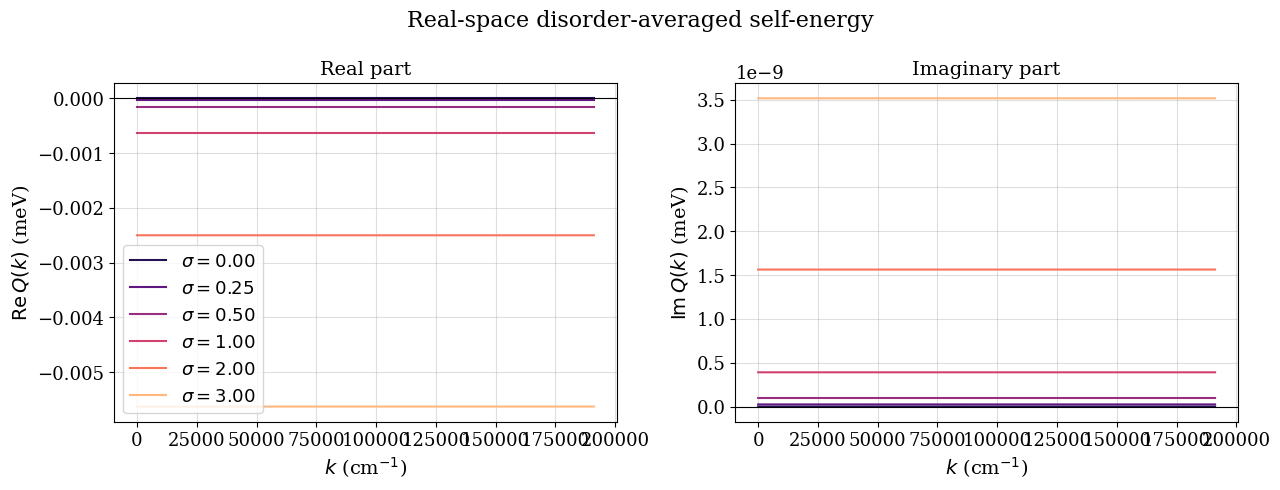

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
ax_re, ax_im = axes

for i, sigma in enumerate(sigmas_q):
	color = CMAP(0.15 + 0.7 * i / max(1, len(sigmas_q) - 1))
	label = fr"$\sigma={1e3*sigma:.2f}$"
	ax_re.plot(k_vals / 100, 1e3 * Q_real[i].real, color=color, label=label)
	ax_im.plot(k_vals / 100, 1e3 * Q_real[i].imag, color=color, label=label)

for ax, ylabel, title in [
	(ax_re, r"$\mathrm{Re}\,Q(k)$ (meV)",  "Real part"),
	(ax_im, r"$\mathrm{Im}\,Q(k)$ (meV)",  "Imaginary part"),
]:
	ax.axhline(0, color='k', lw=0.8)
	ax.set_xlabel(r"$k$ (cm$^{-1}$)")
	ax.set_ylabel(ylabel)
	ax.set_title(title)
	ax.grid(True, alpha=0.4)

ax_re.legend()
fig.suptitle("Real-space disorder-averaged self-energy")
plt.tight_layout()
plt.show()


**Notes**

- Increase `N_q`, `n_shells`, and `n_realizations` for production.
- The finite-grid Green function uses a larger `epsilon` than the CPA calculation by default, because direct real-space resolvents are numerically singular near eigenvalues.
- For an apples-to-apples CPA comparison, use the same disorder correlator, the same on-shell energy, and compare only momenta well below the finite-difference lattice cutoff.


## 5 — Compare against the CPA self-energy

Overplot the real-space $Q_{\rm real}(k)$ extracted above against the CPA
self-energy $Q_{\rm CPA}(k,\eta)$ saved by `Polarition Disorder.ipynb`.

The two parameterisations are matched by

$$\sigma^2 \;=\; \eta\, D_0 / (2\pi\,\xi^2),$$

which follows from the disorder kernel
$\langle V V\rangle_q = \eta\,D_0\,\exp(-\tfrac12 \xi^2 q^2)$
used by `polaritons.kernel`.  We pick, for each real-space $\sigma$, the
closest available $\eta$ in the loaded CPA sweep with matching $\xi$.


Found 4 Q sweeps total, 3 ξ-dependent (gaussian).
  Q_08c2ef   ξ = 40.0 nm
  Q_529b21   ξ = 10.0 nm
  Q_f632ee   ξ = 20.0 nm

Selected CPA sweep stem='Q_f632ee'
  xi  : real-space 20.00 nm   vs   CPA 20.00 nm

  σ (meV)   η (target)     η (closest)
    0.000       0.0000       0.0000
    0.250       0.0070       0.0000
    0.500       0.0278       0.0000
    1.000       0.1112       0.1000
    2.000       0.4448       0.4000
    3.000       1.0009       1.0000


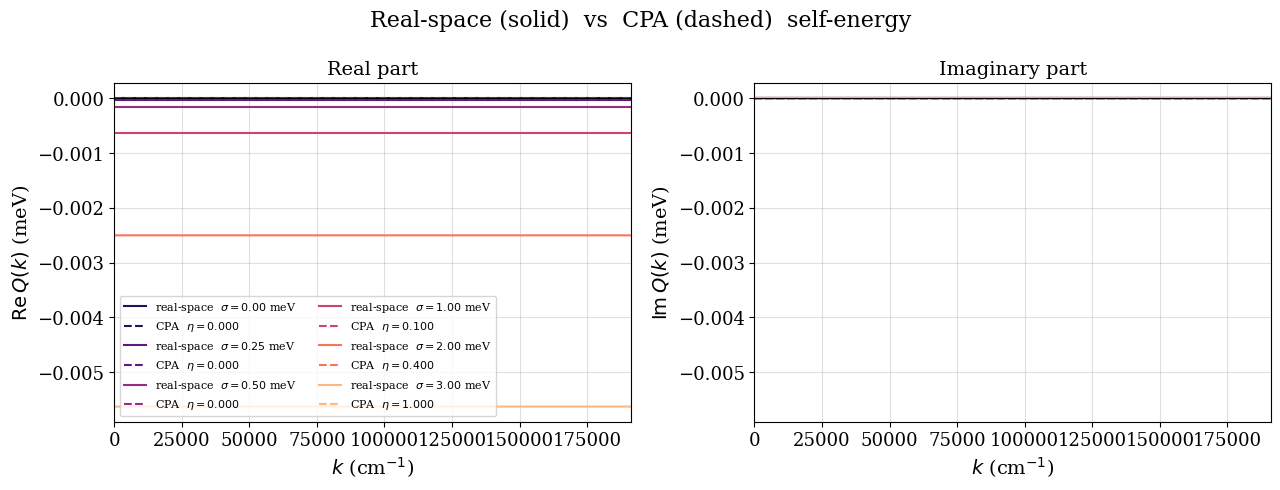

In [20]:
from polaritons.io import list_results, load_result

# ---------------------------------------------------------------------------
# 1. Pick the saved CPA Q sweep whose ξ is closest to the real-space ξ used
#    above (xi_q).  All CPA sweeps live in Results/Q_results.
#    Skip ξ-independent (white-noise / nongaussian) sweeps, which have
#    xi_m = None in their metadata.
# ---------------------------------------------------------------------------
all_q = list_results("Results/Q_results", prefix="Q")
gaussian_q = [
	m for m in all_q
	if m.get("kernel_type") == "gaussian" and m.get("xi_m") is not None
]
print(f"Found {len(all_q)} Q sweeps total, {len(gaussian_q)} ξ-dependent (gaussian).")
for m in gaussian_q:
	print(f"  {m['_stem']}   ξ = {float(m['xi_m'])*1e9:.1f} nm")

if not gaussian_q:
	raise RuntimeError(
		"No ξ-dependent CPA Q sweeps found in Results/Q_results. "
		"Run the gaussian-kernel sweep in 'Polarition Disorder.ipynb' first."
	)

best   = min(gaussian_q, key=lambda m: abs(float(m["xi_m"]) - xi_q))
xi_cpa = float(best["xi_m"])
print(f"\nSelected CPA sweep stem={best['_stem']!r}")
print(f"  xi  : real-space {xi_q*1e9:.2f} nm   vs   CPA {xi_cpa*1e9:.2f} nm")

Q_cpa, meta_cpa = load_result("Results/Q_results", best["_stem"])
eta_grid_cpa = np.asarray(meta_cpa["eta_grid"], dtype=float)
q_picard_nat = np.asarray(meta_cpa["q_picard"], dtype=float)

# Saved params are already in natural units; pull the conversion factors
# directly from the metadata.
p_meta = meta_cpa["params"]
E_unit = float(p_meta["E_unit"])           # eV per natural energy (E_bind)
L_unit = float(p_meta["L_unit"])           # m per natural length (a)
D_0_SI = float(p_meta["D_0"]) * E_unit**2 * L_unit**2

# ---------------------------------------------------------------------------
# 2. Map each real-space σ to the closest η via  σ² = η·D_0 / (2π ξ²).
# ---------------------------------------------------------------------------
eta_from_sigma = (sigmas_q ** 2) * 2 * np.pi * xi_cpa**2 / D_0_SI
idx_eta = np.array([int(np.argmin(np.abs(eta_grid_cpa - e))) for e in eta_from_sigma])

print("\n  σ (meV)   η (target)     η (closest)")
for s, e_t, idx in zip(sigmas_q, eta_from_sigma, idx_eta):
	print(f"  {s*1e3:7.3f}    {e_t:9.4f}    {eta_grid_cpa[idx]:9.4f}")

# Convert the CPA grid to plotting units.
q_cpa_cm = q_picard_nat / L_unit * 1e-2     # 1/m -> cm^-1
positive = q_picard_nat > 0
q_cpa_cm_pos = q_cpa_cm[positive]

# ---------------------------------------------------------------------------
# 3. Side-by-side overlay: real-space (solid) vs CPA (dashed).
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
ax_re, ax_im = axes

for i, (sigma, idx) in enumerate(zip(sigmas_q, idx_eta)):
	color = CMAP(0.15 + 0.7 * i / max(1, len(sigmas_q) - 1))
	label_rs  = fr"real-space  $\sigma={1e3*sigma:.2f}$ meV"
	label_cpa = fr"CPA  $\eta={eta_grid_cpa[idx]:.3f}$"

	ax_re.plot(k_vals / 100, 1e3 * Q_real[i].real, color=color, ls='-',  label=label_rs)
	ax_im.plot(k_vals / 100, 1e3 * Q_real[i].imag, color=color, ls='-',  label=label_rs)

	Q_cpa_meV = Q_cpa[idx, positive] * E_unit * 1e3
	ax_re.plot(q_cpa_cm_pos, Q_cpa_meV.real, color=color, ls='--', label=label_cpa)
	ax_im.plot(q_cpa_cm_pos, Q_cpa_meV.imag, color=color, ls='--', label=label_cpa)

for ax, ylabel, title in [
	(ax_re, r"$\mathrm{Re}\,Q(k)$ (meV)",  "Real part"),
	(ax_im, r"$\mathrm{Im}\,Q(k)$ (meV)",  "Imaginary part"),
]:
	ax.axhline(0, color='k', lw=0.8)
	ax.set_xlabel(r"$k$ (cm$^{-1}$)")
	ax.set_ylabel(ylabel)
	ax.set_title(title)
	ax.set_ylim(-1.05 * np.max(np.abs(Q_real)) * 1e3, 0.05 * np.max(np.abs(Q_real)) * 1e3)
	ax.set_xlim(0, k_vals.max() / 100)
	ax.grid(True, alpha=0.4)

ax_re.legend(fontsize=8, ncol=2)
fig.suptitle("Real-space (solid)  vs  CPA (dashed)  self-energy")
plt.tight_layout()
plt.show()
